# PECD potential vs. SMARD observed generation

How far is "PECD capacity factor x MaStR-derived installed capacity"
(potential -- `de_potential_historic` in `energy-data-hub`, time-varying
fleet) from what SMARD reports Germany actually produced? Some gap is
expected by construction -- outages, curtailment, and (for solar)
behind-the-meter self-consumption all sit between potential and
observed, and none of them are modeled here. This chapter establishes
the gap itself: how big it is, whether it's stable over time, and how
well potential tracks observed generation's actual up-and-down pattern,
independent of its level. Mirrors `pecd-power-validity-DE`'s
`pipeline/16_analyse_potential_vs_observed.py`, rebuilt against the hub's
own (independently derived) potential panel.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from insights.paths import hub_file

TECH_COLORS = {"solar": "#eda100", "wind_onshore": "#2a78d6", "wind_offshore": "#1baf7a"}
POTENTIAL_COLOR = "#7a7a7a"

PAIRS = {
    "solar": ("potential_solar_mw", "pv_mw"),
    "wind_onshore": ("potential_wind_onshore_mw", "wind_onshore_mw"),
    "wind_offshore": ("potential_wind_offshore_mw", "wind_offshore_mw"),
}

## Building the comparison panel

**A known SMARD data issue, already diagnosed in `pecd-power-validity-DE`
and confirmed to affect this hub's own copy of the same data too:**
SMARD's `DE-LU` region query returns implausibly tiny placeholder values
for solar/wind-onshore generation before 2018-10-01 (the DE-LU market
area's actual creation date) -- e.g. June 2017's daily peak is ~87 MW vs.
June 2019's ~30,000 MW, a jump with no real-world capacity story behind
it. Wind offshore/load/price aren't affected (their raw series already
start at/after that date). Trimmed out here rather than treated as
genuine early-year noise.

In [2]:
potential = pd.read_parquet(hub_file("pecd", "de_potential_historic.parquet"))
observed = pd.concat(
    [
        pd.read_parquet(hub_file("smard", "generation_solar.parquet")).rename(columns={"solar": "pv_mw"}),
        pd.read_parquet(hub_file("smard", "generation_wind_onshore.parquet")).rename(columns={"wind_onshore": "wind_onshore_mw"}),
        pd.read_parquet(hub_file("smard", "generation_wind_offshore.parquet")).rename(columns={"wind_offshore": "wind_offshore_mw"}),
    ],
    axis=1,
)

DE_LU_CREATION_DATE = "2018-10-01"
df = potential.join(observed, how="inner").loc[DE_LU_CREATION_DATE:].dropna()
print(f"Joined panel: {df.shape}, {df.index.min()} .. {df.index.max()}")

Joined panel: (63575, 6), 2018-10-01 00:00:00 .. 2025-12-31 22:00:00


## Total installed capacity, per year (for the capacity-factor-normalized view)

Comparing raw MW directly rewards a technology just for having more
capacity; comparing `MW / total installed capacity` (a national capacity
factor) is the more informative, size-independent view. Approximated
here at annual granularity (`capacity_by_region_year`, the panel this
book's other pages already use) rather than `de_potential_historic`'s own
internal monthly resolution -- coarser, but avoids needing a second,
finer capacity panel just for this normalization.

In [3]:
capacity_annual = pd.read_parquet(hub_file("capacity", "capacity_by_region_year.parquet"))
is_offshore = capacity_annual["region_code"].str.startswith("DEZZ")
capacity_by_year = pd.DataFrame({
    "solar": capacity_annual[capacity_annual["technology"] == "solar"].groupby("year")["capacity_mw"].sum(),
    "wind_onshore": capacity_annual[(capacity_annual["technology"] == "wind") & ~is_offshore].groupby("year")["capacity_mw"].sum(),
    "wind_offshore": capacity_annual[(capacity_annual["technology"] == "wind") & is_offshore].groupby("year")["capacity_mw"].sum(),
})
capacity_hourly = capacity_by_year.loc[df.index.year].set_index(df.index)

## Headline comparison

In [4]:
def error_stats(frame: pd.DataFrame, potential_col: str, observed_col: str, capacity_col: pd.Series) -> dict:
    potential_cf = frame[potential_col] / capacity_col
    observed_cf = frame[observed_col] / capacity_col
    err_cf = potential_cf - observed_cf
    err_mw = frame[potential_col] - frame[observed_col]
    mean_observed_mw = frame[observed_col].mean()
    return {
        "n_hours": len(frame),
        "mae_cf": err_cf.abs().mean(),
        "bias_cf": err_cf.mean(),
        "corr_cf": potential_cf.corr(observed_cf),
        "mae_gw": err_mw.abs().mean() / 1000,
        "bias_gw": err_mw.mean() / 1000,
        "corr_mw": frame[potential_col].corr(frame[observed_col]),
        "mean_observed_gw": mean_observed_mw / 1000,
        "nmae_pct": err_mw.abs().mean() / mean_observed_mw * 100,
    }


summary = pd.DataFrame({tech: error_stats(df, p_col, o_col, capacity_hourly[tech]) for tech, (p_col, o_col) in PAIRS.items()}).T

print("Capacity-factor-normalized (size-independent):")
print(summary[["mae_cf", "bias_cf", "corr_cf"]].round(4))
print("\nAbsolute scale (GW) -- the scale a forecast would actually be judged on:")
print(summary[["mean_observed_gw", "mae_gw", "bias_gw", "nmae_pct", "corr_mw"]].round(2))

Capacity-factor-normalized (size-independent):
               mae_cf  bias_cf  corr_cf
solar          0.0146   0.0092   0.9816
wind_onshore   0.0292   0.0184   0.9857
wind_offshore  0.0835   0.0582   0.9020

Absolute scale (GW) -- the scale a forecast would actually be judged on:
               mean_observed_gw  mae_gw  bias_gw  nmae_pct  corr_mw
solar                      6.10    1.08     0.79     17.73     0.98
wind_onshore              12.00    1.71     1.08     14.22     0.99
wind_offshore              2.86    0.71     0.50     24.68     0.90


## What the gap looks like over time

Monthly-mean potential vs. observed, full available history.

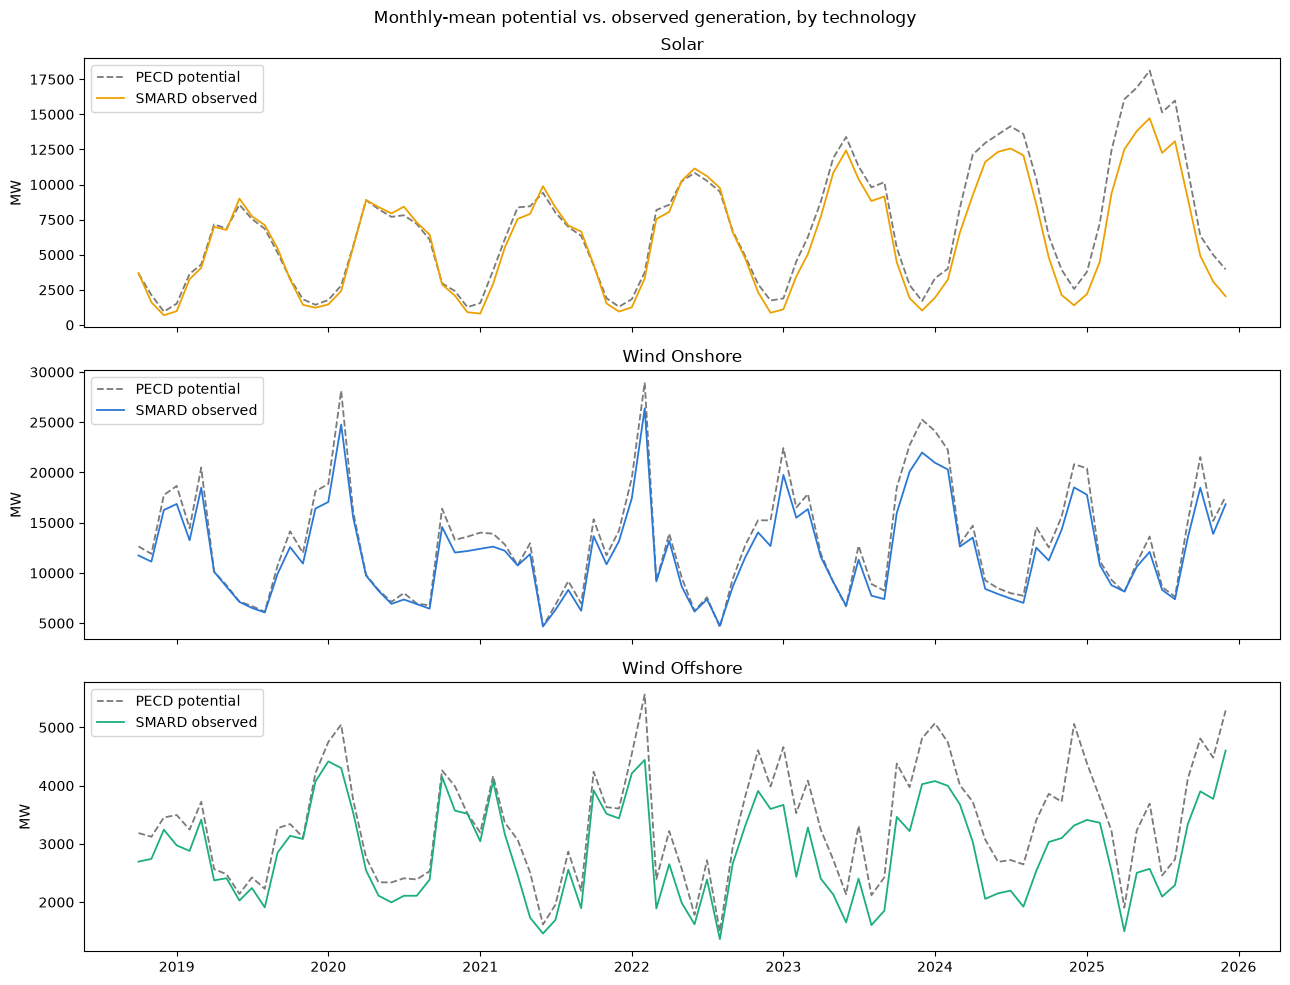

In [5]:
monthly = df.resample("MS").mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, tech in zip(axes, PAIRS):
    p_col, o_col = PAIRS[tech]
    ax.plot(monthly.index, monthly[p_col], label="PECD potential", color=POTENTIAL_COLOR, linewidth=1.3, linestyle="--")
    ax.plot(monthly.index, monthly[o_col], label="SMARD observed", color=TECH_COLORS[tech], linewidth=1.3)
    ax.set_ylabel("MW")
    ax.set_title(tech.replace("_", " ").title())
    ax.legend(loc="upper left")
fig.suptitle("Monthly-mean potential vs. observed generation, by technology")
fig.tight_layout()
plt.show()

Potential should sit visibly above observed for all three technologies
(nothing has been subtracted from it yet) -- and if the gap isn't flat
over time, that's a real pattern (curtailment, self-consumption growth),
not a modeling error.

## A closer look: three weeks, hourly

The monthly view above shows the *level* gap; this zooms in on whether
potential tracks observed generation's actual hour-to-hour shape, not
just its rough level.

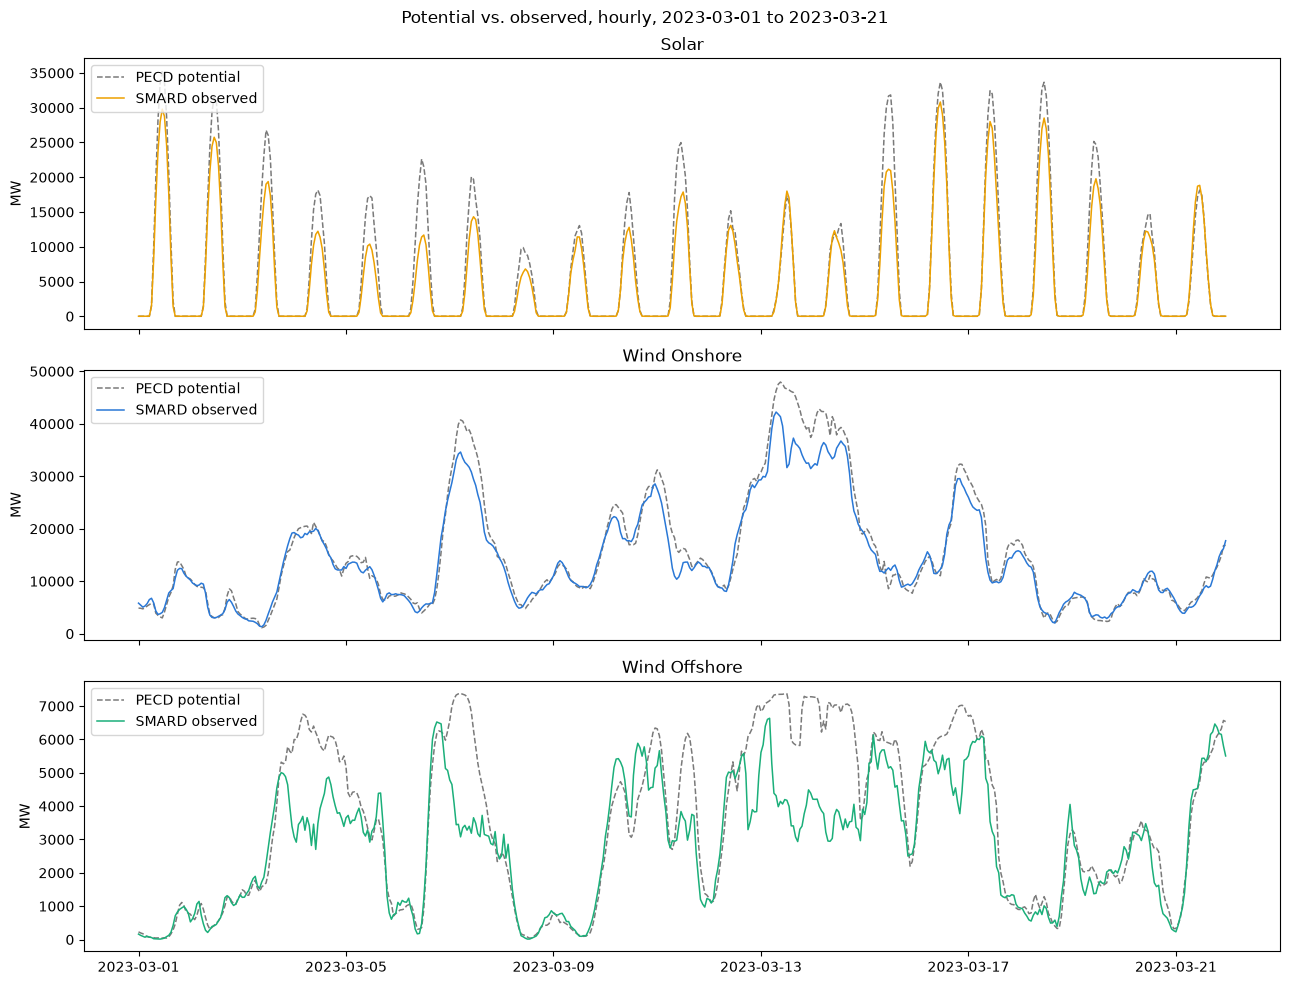

In [6]:
zoom_window = df.loc["2023-03-01":"2023-03-21"]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, tech in zip(axes, PAIRS):
    p_col, o_col = PAIRS[tech]
    ax.plot(zoom_window.index, zoom_window[p_col], label="PECD potential", color=POTENTIAL_COLOR, linewidth=1.1, linestyle="--")
    ax.plot(zoom_window.index, zoom_window[o_col], label="SMARD observed", color=TECH_COLORS[tech], linewidth=1.1)
    ax.set_ylabel("MW")
    ax.set_title(tech.replace("_", " ").title())
    ax.legend(loc="upper left")
fig.suptitle("Potential vs. observed, hourly, 2023-03-01 to 2023-03-21")
fig.tight_layout()
plt.show()

## Scatter view: potential vs. observed, capacity-factor terms

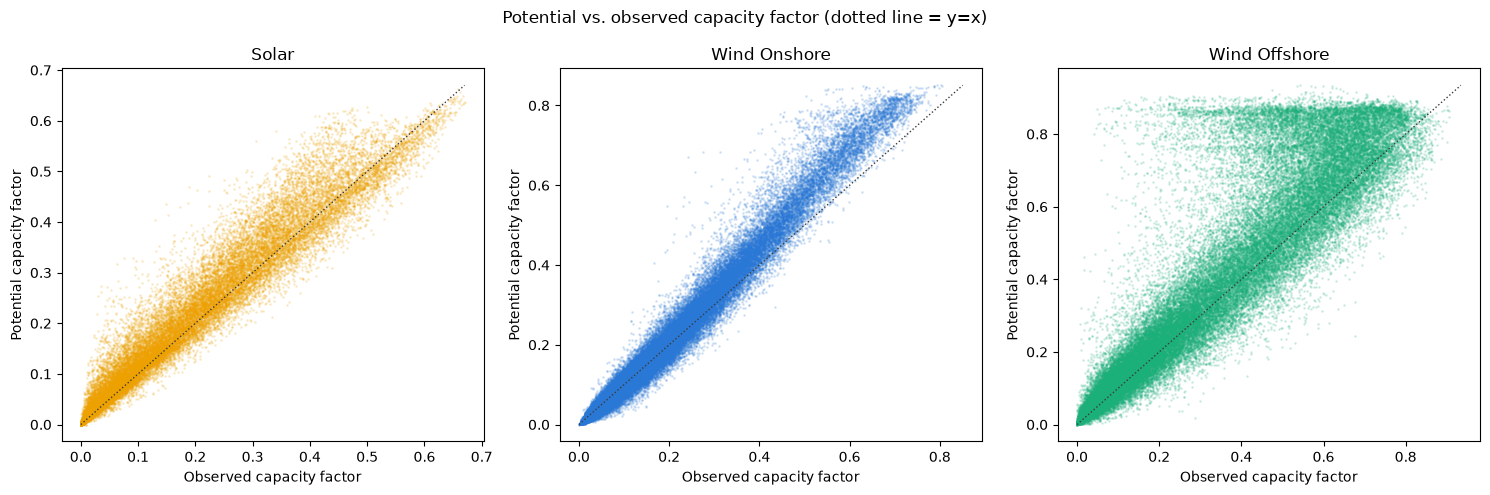

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tech in zip(axes, PAIRS):
    p_col, o_col = PAIRS[tech]
    p_cf, o_cf = df[p_col] / capacity_hourly[tech], df[o_col] / capacity_hourly[tech]
    ax.scatter(o_cf, p_cf, s=1, alpha=0.15, color=TECH_COLORS[tech], rasterized=True)
    lims = [0, max(p_cf.max(), o_cf.max())]
    ax.plot(lims, lims, color="#3a3a3a", linewidth=1, linestyle=":")
    ax.set_xlabel("Observed capacity factor")
    ax.set_ylabel("Potential capacity factor")
    ax.set_title(tech.replace("_", " ").title())
fig.suptitle("Potential vs. observed capacity factor (dotted line = y=x)")
fig.tight_layout()
plt.show()

Points above the `y=x` line are hours where potential overstates
observed generation. A systematic tilt above the line, especially at
higher capacity factors, is the signature curtailment and outages are
expected to leave -- more available power is exactly when curtailment is
most likely to bind.

## Scatter view: the same hours, absolute GW

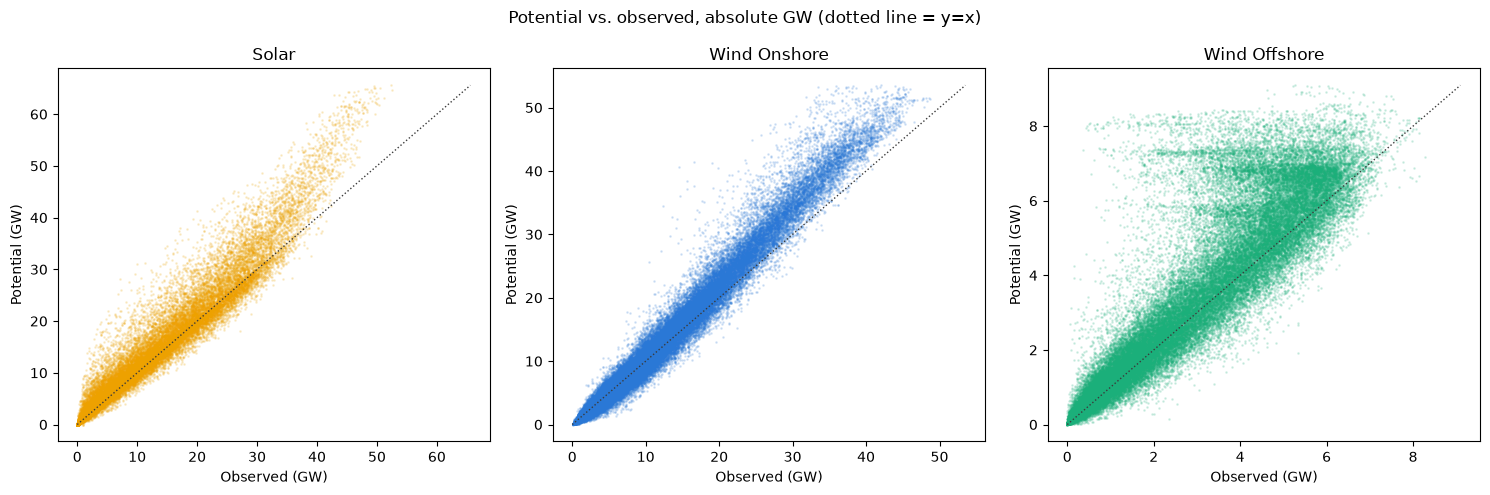

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tech in zip(axes, PAIRS):
    p_col, o_col = PAIRS[tech]
    sub = df[[p_col, o_col]] / 1000  # MW -> GW
    ax.scatter(sub[o_col], sub[p_col], s=1, alpha=0.15, color=TECH_COLORS[tech], rasterized=True)
    lims = [0, max(sub[p_col].max(), sub[o_col].max())]
    ax.plot(lims, lims, color="#3a3a3a", linewidth=1, linestyle=":")
    ax.set_xlabel("Observed (GW)")
    ax.set_ylabel("Potential (GW)")
    ax.set_title(tech.replace("_", " ").title())
fig.suptitle("Potential vs. observed, absolute GW (dotted line = y=x)")
fig.tight_layout()
plt.show()

## Takeaways

- The capacity-factor-normalized row above lands close to
  `pecd-power-validity-DE`'s own published numbers for the same
  comparison (solar MAE 0.016/corr 0.981, wind onshore MAE 0.029/corr
  0.985, wind offshore MAE 0.094/corr 0.902) -- despite this hub's
  potential panel being built by a completely independent pipeline (its
  own MaStR ingestion + region crosswalk, not that project's processed
  outputs). That agreement is a real external validation of the
  capacity-weighting logic (`edh/pecd.py`), not just an internally
  consistent one.
- Potential tracks observed generation's actual weather-driven shape
  well for all three technologies (the zoomed-in view) -- the gap is
  overwhelmingly a *level* difference, not a timing mismatch.
- The gap is not constant over time (the monthly view) and tilts upward
  at higher output levels (the scatter view) -- both consistent with
  curtailment (which binds hardest exactly when potential output is
  highest) rather than a simple constant unavailability rate.
- Capacity-factor terms and absolute GW terms can rank the three
  technologies differently: a technology with more installed capacity
  tends to show a larger absolute (GW) error even when its
  capacity-factor-normalized error is small, simply because it carries
  more capacity -- "how good is this model" and "how big is this error
  in practice" are different questions, both reported above rather than
  picking one.